#### Dataset

In [2]:
# imagenet-new.zip
# https://mitu.co.in/dataset

#### Import the libraries

In [5]:
from keras.models import Sequential
from keras.layers import Dense, Input, Conv2D, MaxPool2D, Flatten, Dropout
from keras.utils import plot_model, to_categorical
import cv2
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#### Create data generator objects

In [8]:
train_datagen = ImageDataGenerator(rescale=1/255, zoom_range=0.2, 
                                  horizontal_flip=True, shear_range=0.2)

In [19]:
train = train_datagen.flow_from_directory(
    'datasets/imagenet-new/train',
    class_mode='categorical', target_size=(64,64))

Found 5000 images belonging to 10 classes.


In [20]:
train.class_indices

{'crocodile': 0,
 'fish': 1,
 'fossils': 2,
 'frog': 3,
 'insect': 4,
 'reptiles': 5,
 'scorpion': 6,
 'snake': 7,
 'spider': 8,
 'toad': 9}

#### Build the model

In [21]:
model = Sequential()

model.add(Input(shape=(64,64,3)))

model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(10, activation='softmax'))

In [22]:
model.compile(loss='categorical_crossentropy', optimizer='adam',
             metrics=['accuracy'])

In [23]:
model.fit(train, epochs=20, batch_size=10)

Epoch 1/20


/home/mitu/.local/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.1784 - loss: 2.1974
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.3734 - loss: 1.8004
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.4113 - loss: 1.6493
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - accuracy: 0.4643 - loss: 1.5226
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.4977 - loss: 1.4574
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 82ms/step - accuracy: 0.5219 - loss: 1.4046
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.5219 - loss: 1.3643
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.5638 - loss: 1.3033
Epoch 9/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.5686 - loss: 1.2760
Epoch 10/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.5877 - loss: 1.2213
Epoch 11/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - accuracy: 0.5924 - loss: 1.1729
Epoch 12/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1

#### Predict the class of an image

In [28]:
res = dict((v,k) for k, v in train.class_indices.items())

In [29]:
res

{0: 'crocodile',
 1: 'fish',
 2: 'fossils',
 3: 'frog',
 4: 'insect',
 5: 'reptiles',
 6: 'scorpion',
 7: 'snake',
 8: 'spider',
 9: 'toad'}

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step


'spider'

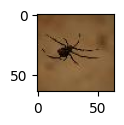

In [33]:
img = plt.imread('datasets/imagenet-new/val/images/val_192.JPEG')
plt.figure(figsize=(1,1))
plt.imshow(img)
img = img.reshape(1,64,64,3)
pred = model.predict(img)
res[pred.argmax()]